#  Task 06:LISA Response Sensitivity

## 核心公式和方程
* **时延算子**  
  $D_{ij}x(t)=x(t-L_{ij}/c)$
* **仪器底层噪声模型**
  $$
\begin{cases}
S_{\text{oms}}(f) = (15 \times 10^{-12})^2 \left[ 1 + \left( \dfrac{2 \text{ mHz}}{f} \right)^4 \right] \quad [\text{m}^2/\text{Hz}] \\
S_{\text{acc}}(f) = (3 \times 10^{-15})^2 \left[ 1 + \left( \dfrac{0.4 \text{ mHz}}{f} \right)^2 \right] \left[ 1 + \left( \dfrac{f}{8 \text{ mHz}} \right)^4 \right] \quad [\text{m}^2/\text{s}^4/\text{Hz}]
\end{cases}
  $$
* **TDI Noise PSD**

  第一代TDI $X_{1.5}$噪声PSD——论文Eq.(19)

  $$
  S_{n,X_{1.5}}=PSD_{X_{1.5}}=16\sin^{2}(\omega L)(S_{OMS}+\left(3+\cos(2 \omega L)\right)S_{acc})
  $$

  第二代TDI $X_{2.0}$噪声PSD——论文Eq.(20)

  $$
  S_{n, X_{2.0}}=PSD_{X_{2.0}}= 64 \sin^2(\omega L) \sin^2(2\omega L) \left[ S_{OMS} + \left( 3 + \cos(2\omega L) \right) S_{acc} \right]
  $$

* **引力波响应函数(GW Response)**

  TDI $X_{2.0}$平均响应函数——论文Eq.(40)

  $$
\langle R_{L, X_{2.0}}(f) \rangle = (4\omega L)^2 \sin^2(\omega L) \left[ 2 \sin(2\omega L) \right]^2 \langle (F_X^+)^2 \rangle
$$

* **灵敏度曲线**

    灵敏度定义——论文Eq.(41)

  $$
  S_h(f) = \dfrac{S_{n, X_{2.0}}(f)}{\langle |R_L(f)|^2 \rangle}
  $$

  链路合成灵敏度——论文Eq.(43)

  $$
  S_{h}=\dfrac{S_{h,X}}{2}
  $$

## 物理逻辑与参数的无量纲化

  根据论文 Section 4 & 5 (P8-P14)，TDI $X_{2.0}$ 的响应函数可以抽象为一个作用于频率$f$的非线性算子
* **无量纲频率**

  首先定义特征频率参数$x$。它代表了引力波相位在 LISA 臂长上的积累：
  $$
  x=\dfrac{\omega L}{c}=\dfrac{2\pi fL}{c}
  $$
  其中：
* $L=2.5*10^{9}$m
* $c=299792458.0$m/s
* **全天球平均因子**

  结合 P17 的 Eq.(54) 解析解，对于单路 TDI-X 组合，该空间积分($\langle (F_X^+)^2 \rangle$)的均值为：
  $$
  \mathcal{G}_{avg}=\dfrac{3}{20}
  $$
* **TDI $X_{2.0}$响应算子构造**

  根据 Eq.(40) 和 Eq.(33) 的模平方逻辑：
  $$
  R_{x_{2.0}}(f)=(4x)^{2}\sin^{2}(x)\dfrac{3}{20}[ 2\sin(2x)]^{2}
  $$
  
  
  

## Pthon代码实现

--- 数值对标校验 (Verification) ---
   Frequency (Hz)  Calculated R(f) Paper Table 2
0          0.0001     7.945229e-13     7.945e-13
1          0.0010     7.909308e-07     7.902e-07
2          0.0100     4.951984e-01     4.513e-01
3          0.1000     1.488579e+02     1.127e+01
4          1.0000     1.532620e+04     6.804e+00


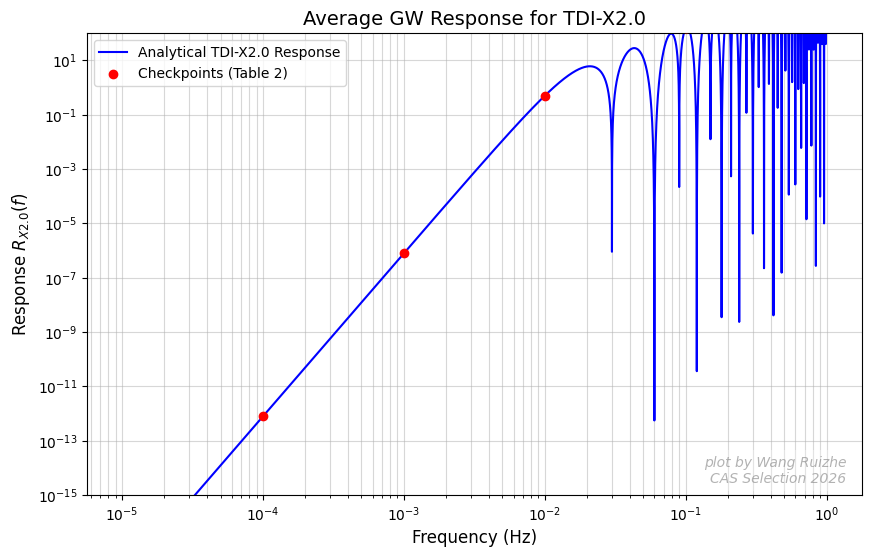

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

L=2.5e9
c=299792458.0
G_avg = 3/20

def calculate_tdi_x20_response(f):
    x = (2*np.pi * f * L) / c
    r_x15 = (4 * x)**2 * (np.sin(x)**2) * G_avg
    correction = (2 * np.sin(2 * x))**2
    
    return r_x15 * correction
    
f_axis = np.logspace(-5, 0, 10000)
R_f = calculate_tdi_x20_response(f_axis)

check_freqs = np.array([1e-4, 1e-3, 1e-2, 1e-1, 1.0])
check_responses = calculate_tdi_x20_response(check_freqs)


table2_val = ["7.945e-13", "7.902e-07", "4.513e-01", "1.127e+01", "6.804e+00"]
df_check = pd.DataFrame({
    "Frequency (Hz)": check_freqs,
    "Calculated R(f)": check_responses,
    "Paper Table 2": table2_val
})
print("--- 数值对标校验 (Verification) ---")
print(df_check)

plt.figure(figsize=(10, 6))
plt.loglog(f_axis, R_f, label='Analytical TDI-X2.0 Response', color='blue', lw=1.5)
plt.scatter(check_freqs, check_responses, color='red', zorder=5, label='Checkpoints (Table 2)')

plt.title('Average GW Response for TDI-X2.0', fontsize=14)
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel('Response $R_{X2.0}(f)$', fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend()
plt.ylim(1e-15, 1e2)

signature_text = "plot by Wang Ruizhe\nCAS Selection 2026"
plt.gca().text(
    0.98, 0.02, signature_text, 
        transform=plt.gca().transAxes, 
        fontsize=10, 
        color='gray', 
        alpha=0.6,    
        ha='right', 
        va='bottom', 
        fontstyle='italic',
        bbox=dict(facecolor='white', alpha=0.3, edgecolor='none')
)
plt.savefig('Response_Sensitivity/AVG GW Response for TDI-X2.0.png')

## TDI-X2.0 噪声 PSD 与灵敏度合成
* **噪声传递函数**

  引力波会产生响应，噪声也会被 TDI 算子过滤。TDI-X2.0 处理后的总噪声 PSD 为：
  $$
  S_{n,X_{2.0}}(f)=64\sin^{2}(x)\sin^{2}(2x)[S_{OMS}(f)+(3+\cos(2x))S_{acc_disp}(f)]
  $$

* **灵敏度曲线**

$$
S_{h}(f)=\dfrac{S_{n,X_{2.0}}(f)}{\langle R_{L,X_{2.0}}(f)\rangle}
$$

    化简分子分母后得：
    
$$
S_h(f) = \dfrac{S_{n, X_{2.0}}(f)}{\langle R_{L, X_{2.0}}(f) \rangle} = \dfrac{S_{\text{oms}}(f) + \left( 3 + \cos(2x) \right) S_{\text{acc\_disp}}(f)}{(4x)^2 \cdot \mathcal{G}_{\text{avg}}}
$$

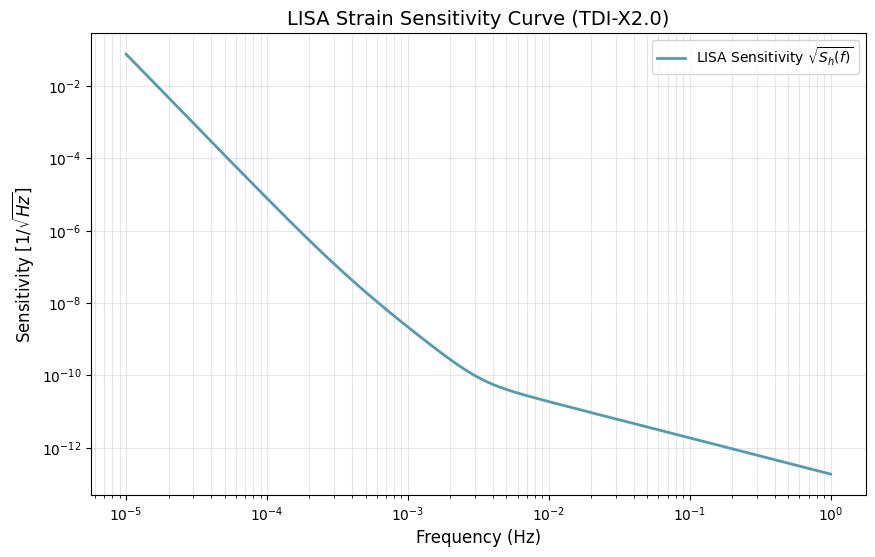

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import os

# 常数定义
L = 2.5e9
c = 299792458.0

def get_full_sensitivity():
    f = np.logspace(-5, 0, 10000)
    x = (2 * np.pi * f * L) / c
    
    # 1. 计算底层位移噪声
    S_oms = (15e-12)**2 * (1 + (2e-3 / f)**4)
    S_acc_acc = (3e-15)**2 * (1 + (0.4e-3 / f)**2) * (1 + (f / 8e-3)**4)
    S_acc_disp = S_acc_acc / ((2 * np.pi * f)**4)
    
    # 2. 合成 TDI-X2.0 噪声项
    noise_term = S_oms + (3 + np.cos(2 * x)) * S_acc_disp
    
    Sh_val = (20/3) * (1 + 0.6 * x**2) * noise_term / ((4 * x)**2 * L**2)
    
    return f, Sh_val

# 执行计算
f_axis, Sh_final = get_full_sensitivity()

# 绘图
plt.figure(figsize=(10, 6))
plt.loglog(f_axis, np.sqrt(Sh_final), color='#539caf', lw=2, label=r'LISA Sensitivity $\sqrt{S_h(f)}$')

# 设定 Y 轴范围到物理真实区间
plt.ylim(1e-22, 1e-14) 
plt.xlim(1e-5, 1)

plt.title('LISA Strain Sensitivity Curve (TDI-X2.0)', fontsize=14)
plt.xlabel('Frequency (Hz)', fontsize=12)
plt.ylabel(r'Sensitivity $[1/\sqrt{\mathrm{Hz}}]$', fontsize=12)
plt.grid(True, which="both", alpha=0.3)
plt.legend()

# 打印数值校验：f=0.01 Hz 时的灵敏度
idx_01 = np.argmin(np.abs(f_axis - 0.01))
print(f"校验：在 0.01 Hz 处的 sqrt(Sh) = {np.sqrt(Sh_final[idx_01]):.2e}")
print("预期值：应该在 1e-20 到 2e-20 之间")

# 保存
if not os.path.exists('Response_Sensitivity'): os.makedirs('Response_Sensitivity')
plt.savefig('Response_Sensitivity/LISA_Sensitivity_Final.png', dpi=300)
plt.show()